In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load and combine the data files
files = [
    "data/prices_round_1_day_-2.csv",
    "data/prices_round_2_day_-1.csv",
    "data/prices_round_3_day_0.csv",
    "data/prices_round_4_day_1.csv",
    "data/prices_round_4_day_2.csv",
    "data/prices_round_4_day_3.csv"
]

df_list = []
timestamp_offset = 0

for file in files:
    if os.path.exists(file):
        df = pd.read_csv(file, sep=';')
        df['timestamp'] += timestamp_offset
        timestamp_offset = df['timestamp'].max() + 1
        df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

# Filter data for RAINFOREST_RESIN
resin_data = data[data['product'] == 'RAINFOREST_RESIN'].copy()

# Preview of the data
print(resin_data.head())


    day  timestamp           product  bid_price_1  bid_volume_1  bid_price_2  \
0    -2          0  RAINFOREST_RESIN       9996.0           1.0       9995.0   
4    -2        100  RAINFOREST_RESIN      10000.0           5.0       9995.0   
8    -2        200  RAINFOREST_RESIN       9996.0           1.0       9995.0   
9    -2        300  RAINFOREST_RESIN       9996.0           1.0       9995.0   
12   -2        400  RAINFOREST_RESIN       9995.0          20.0          NaN   

    bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
0           25.0          NaN           NaN        10004             1   
4           20.0          NaN           NaN        10005            20   
8           30.0          NaN           NaN        10004             1   
9           26.0          NaN           NaN        10004             1   
12           NaN          NaN           NaN         9998             3   

    ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  \
0  

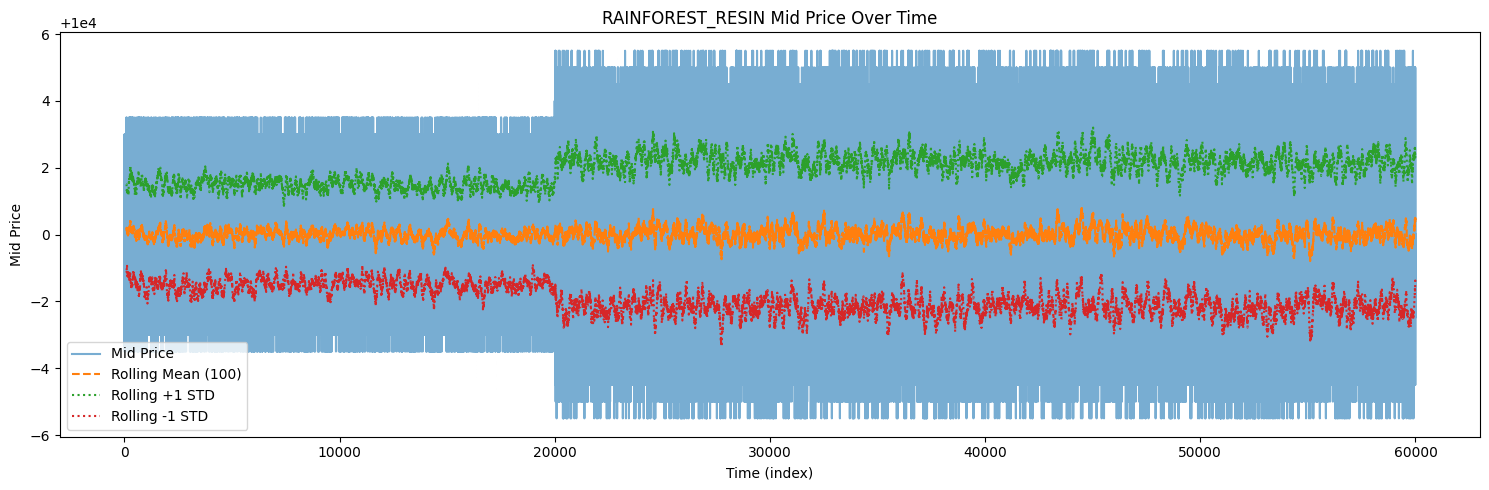

count    60000.000000
mean     10000.005408
std          1.983154
min       9994.500000
25%      10000.000000
50%      10000.000000
75%      10000.000000
max      10005.500000
Name: mid_price, dtype: float64

In [17]:
# Plot the mid price history and show some basic stats to guide strategy design
mid_price_series = resin_data["mid_price"].dropna().reset_index(drop=True)

# Compute rolling mean and std for visualization
rolling_mean = mid_price_series.rolling(window=100).mean()
rolling_std = mid_price_series.rolling(window=100).std()

# Plot mid price with rolling stats
plt.figure(figsize=(15, 5))
plt.plot(mid_price_series, label="Mid Price", alpha=0.6)
plt.plot(rolling_mean, label="Rolling Mean (100)", linestyle="--")
plt.plot(rolling_mean + rolling_std, label="Rolling +1 STD", linestyle=":")
plt.plot(rolling_mean - rolling_std, label="Rolling -1 STD", linestyle=":")
plt.title("RAINFOREST_RESIN Mid Price Over Time")
plt.xlabel("Time (index)")
plt.ylabel("Mid Price")
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
mid_price_stats = mid_price_series.describe()
mid_price_stats


In [18]:
print(resin_data['day'].unique())

[-2 -1  0  1  2  3]


Final PnL: 0.0
Final Inventory: 0
Final Cash: 0
Final Mid Price: 10000.0
Number of Trades: 0


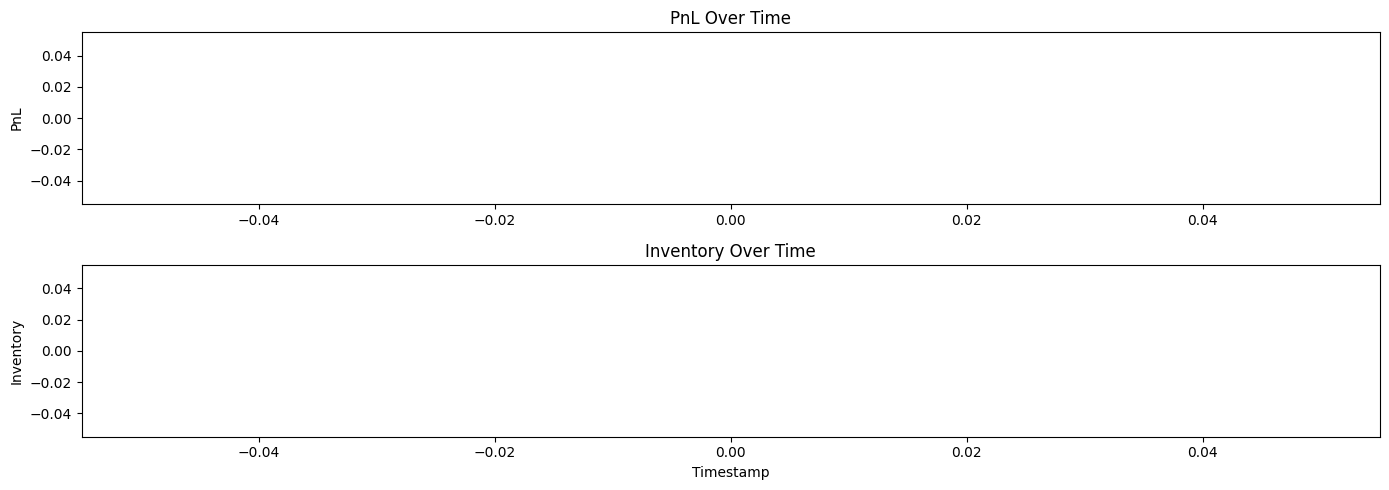

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
POSITION_LIMIT = 50
ORDER_SIZE = 5
inventory = 0
cash = 0
trades = []

# Ensure data is sorted
resin_data = resin_data.sort_values("timestamp").reset_index(drop=True)

# Run market making logic
for _, row in resin_data.iterrows():
    mid = row["mid_price"]
    timestamp = row["timestamp"]
    bid_price_1 = row["bid_price_1"]
    ask_price_1 = row["ask_price_1"]

    if pd.isna(mid) or pd.isna(bid_price_1) or pd.isna(ask_price_1):
        continue

    # Our quotes: inside spread
    my_bid = mid - 1
    my_ask = mid + 1

    # Simulate buy fill
    if my_bid >= ask_price_1 and inventory + ORDER_SIZE <= POSITION_LIMIT:
        inventory += ORDER_SIZE
        cash -= ORDER_SIZE * ask_price_1
        trades.append((timestamp, "BUY", ask_price_1, ORDER_SIZE, inventory, cash))

    # Simulate sell fill
    if my_ask <= bid_price_1 and inventory - ORDER_SIZE >= -POSITION_LIMIT:
        inventory -= ORDER_SIZE
        cash += ORDER_SIZE * bid_price_1
        trades.append((timestamp, "SELL", bid_price_1, ORDER_SIZE, inventory, cash))

# Create trade log
trade_df = pd.DataFrame(trades, columns=["timestamp", "side", "price", "qty", "inventory", "cash"])

# Final mark-to-market value
final_mid_price = resin_data["mid_price"].dropna().iloc[-1]
final_pnl = cash + inventory * final_mid_price

# Print summary
print("Final PnL:", round(final_pnl, 2))
print("Final Inventory:", inventory)
print("Final Cash:", round(cash, 2))
print("Final Mid Price:", final_mid_price)
print("Number of Trades:", len(trade_df))

# Plot cash value over time
trade_df["pnl"] = trade_df["cash"] + trade_df["inventory"] * final_mid_price

plt.figure(figsize=(14, 5))
plt.subplot(2, 1, 1)
plt.plot(trade_df["timestamp"], trade_df["pnl"])
plt.title("PnL Over Time")
plt.ylabel("PnL")

plt.subplot(2, 1, 2)
plt.plot(trade_df["timestamp"], trade_df["inventory"])
plt.title("Inventory Over Time")
plt.ylabel("Inventory")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()


